In [1]:
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
df = pd.read_csv("data/STAR_throughput.csv").sort_values(["srr_size_MiB", "ebs_throughput"]).reset_index(drop=True)

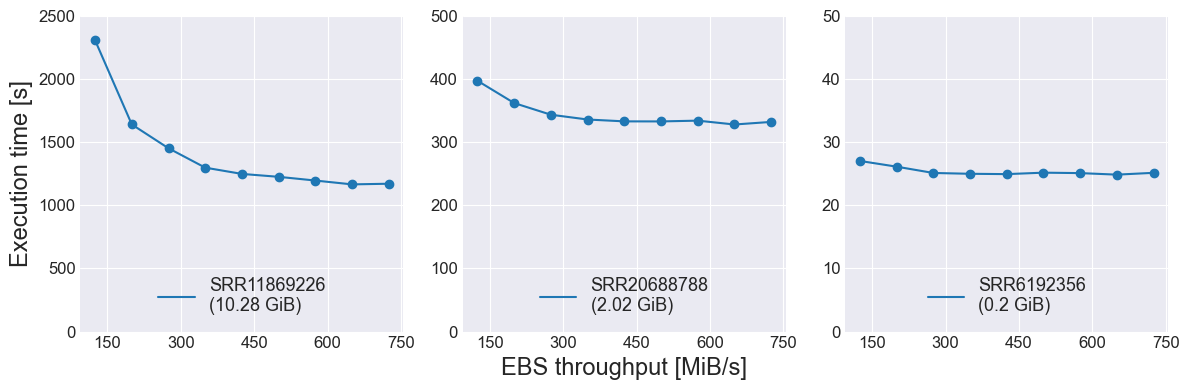

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

for i, (group_name, group_data) in enumerate(df.groupby("srr_id")):
    ax = axes[i]
    ax.scatter(group_data["ebs_throughput"], group_data['execution_time_seconds'])
    ax.plot(group_data["ebs_throughput"], group_data['execution_time_seconds'], label=f"{group_name}\n({round(group_data['srr_size_MiB'].iloc[0].item() / 1024, 2)} GiB)")

    ax.set_xticks([150, 300, 450, 600, 750])
    if i == 0:
        ax.set_ylabel('Execution time [s]', fontsize=17)
        ax.set_yticks([0, 500, 1000, 1500, 2000, 2500])

    if i == 1:
        ax.set_xlabel('EBS throughput [MiB/s]', fontsize=17)
        ax.set_yticks([0, 100, 200, 300, 400, 500])
    if i == 2:
        ax.set_yticks([0, 10, 20 ,30, 40, 50])
    ax.legend(loc="lower center", fontsize=13)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.savefig("plots/STAR_throughput.pdf", bbox_inches='tight')
plt.show()